# Cheap LLM judge and baseline scores for NL→FOL translations (Experiment D)

This notebook is a runnable demo of **Experiment D**, the baseline (null) arm of a study on **gold-free quality metrics
for natural-language → first-order-logic (NL→FOL) translation**.

**The question.** You have a sentence and a candidate FOL formula from some system, and no gold formula. How well do
the *cheap, existing* checks predict whether the formula is **faithful** to the sentence? Any new metric has to beat
the bar these checks set.

**The data.** The *shared frozen screen*. **Track L** holds 796 Logic-LM outputs (gpt-3.5-turbo, gpt-4 and
text-davinci-003) on FOLIO-dev sentences. Each output is labelled against a corrected gold formula or an agreed
premise using a **z3-checked equivalence modulo vocabulary** labeller: CORRECT, ERROR, UNCERTAIN or UNPARSEABLE.

**The baselines scored on every item** (all oriented so that *higher = more likely unfaithful*):
* parse / compile failure;
* the user's pilot *structural* metrics: joint-conflict with the story (z3 UNSAT), arity/shape clashes, dangling or
  undeclared predicates, and cross-system predicate Jaccard;
* **round-trip** metrics: an LLM verbalises FOL→NL, then NLI entailment both ways, mpnet cosine, and re-formalisation
  equivalence;
* **LLM judges**: `gemini-2.5-flash-lite` (JSON 0–100) and `gpt-4.1-nano` (P(YES)). Each judges the *original* item
  and a **disguised** copy in which content words are replaced by nonce words, to test for contamination. A frontier
  judge, `gemini-3.1-pro-preview`, scores a pre-registered subsample.

**What runs here.** The original `method.py` is a multi-stage pipeline. Its LLM, NLI and GPU stages need API keys and a
GPU, so this demo loads their **cached per-item scores** from `mini_demo_data.json`: 100 curated track-L items,
balanced CORRECT/ERROR, plus a few UNCERTAIN and UNPARSEABLE items. The notebook then re-runs the parts of the
pipeline that need no API calls, **with the original code**:
1. the FOL grammar + **z3 equivalence** used by the labeller (`src/labeller/fol.py`);
2. the whole **meta-evaluation** (`src/analysis.py` + `src/report.py`, i.e. `method.py --stage analysis`). This
   covers AUROC with sentence-clustered bootstrap CIs, thresholded FA/recall, paired ΔAUROC vs the judge with a
   DeLong test, the disguise (contamination) deltas, the cross-fitted combination of all cheap baselines, complexity
   strata and system level.

Full-run headline on track L (n=524): **judge_cheap_disg AUROC 0.777** (the bar); rt_nli_min 0.710; pilot
structural metrics 0.50–0.53 (a negative result); cross-fitted combination of all cheap baselines 0.817.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

In [2]:
# --- original method.py import block ---
import argparse
import asyncio
import json
import os
import sys
import time
from collections import Counter
from pathlib import Path

os.environ.setdefault("PYTHONHASHSEED", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sys.setrecursionlimit(10000)

from loguru import logger  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")  # (file sink logs/run.log dropped in the notebook)

# --- imports of the src/ modules inlined below (common.py, labeller/fol.py, analysis.py, report.py) ---
import hashlib
import math
import re
from collections import defaultdict

import numpy as np
import z3
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

# --- notebook-only: results table + plots ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["datasets"][0]["dataset"], "-", len(data["datasets"][0]["examples"]), "examples")
print("label counts:", dict(Counter(e["output"] for e in data["datasets"][0]["examples"])))

shared_screen_trackL_logiclm_folio_dev - 100 examples
label counts: {'ERROR': 42, 'UNPARSEABLE': 8, 'CORRECT': 42, 'UNCERTAIN': 8}


## Configuration

Every tunable parameter is set here. The analysis is cheap, so the demo uses the **original** values: 2,000
cluster-bootstrap resamples, 5 GroupKFold folds and a 5 s z3 timeout, on all 100 demo items. The full run used the same
settings on 1,090 screen items plus 282 rewrites.

In [5]:
MAX_ITEMS = 100        # demo items to use (the full screen has 1,090 items; the demo file holds 100 track-L items)
B_RESAMPLES = 2000     # sentence-clustered bootstrap resamples (original: 2000)
SEED = 0               # bootstrap / fold seed (original: 0)
N_SPLITS = 5           # GroupKFold folds for the cross-fitted baseline combination (original: 5)
C_LOGREG = 1.0         # L2 logistic-regression strength of the combination (original: 1.0)
Z3_MS = 5000           # z3 timeout (ms) per equivalence check in the labeller (original: 5000)
N_LABEL_ITEMS = 100    # items whose label is re-checked with z3 (original: every screen item)
N_T6_ITEMS = 10        # EQUIV items used for the negated-consequent sanity check (original: 10)

## 1. Shared helpers (`src/common.py`)

`norm()` normalises a sentence. Its output is the **cluster id** for every bootstrap and for the GroupKFold split,
because the three Logic-LM systems translate the same sentences, so items that share a sentence are not independent.
`sha1()` hashes strings for item ids and pre-registration.

In [6]:
_QUOTES = str.maketrans({"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "−": "-"})


def norm(s: str) -> str:
    s = (s or "").translate(_QUOTES).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

### Build the screen items from the demo data

In the original, `screen_items()` reads `data/screen_items.json`. Here each demo example carries the same fields as
`metadata_*`, together with the `input` (text + candidate FOL) and the cached oriented scores as `predict_*`. The
next cell turns every example back into a screen-item dict.

In [7]:
EXAMPLES = data["datasets"][0]["examples"][:MAX_ITEMS]


def screen_items() -> list[dict]:
    items = []
    for e in EXAMPLES:
        inp = json.loads(e["input"])
        r = {k[len("metadata_"):]: v for k, v in e.items() if k.startswith("metadata_")}
        r.update(text=inp["text"], candidate_fol=inp["candidate_fol"])
        items.append(r)
    return items


items = screen_items()
byid = {r["item_id"]: r for r in items}
r0 = items[0]
print(f"{len(items)} items; example:\n  text      : {r0['text']}\n  candidate : {r0['candidate_fol']}\n"
      f"  reference : {r0['reference_fol']}\n  label     : {r0['label']} ({r0['auto_class']}, ops={r0['repair_ops']})")

100 items; example:
  text      : The world championships is a sporting event.
  candidate : SportingEvent(worldChampionships)
  reference : SportingEvent(champs)
  label     : ERROR (ERROR, ops=['BIND'])


## 2. FOL grammar and z3 equivalence (`src/labeller/fol.py`)

The labeller parses FOLIO/MALLS Unicode FOL into an AST and checks **validity of `cand ↔ ref`** with z3 over an
uninterpreted sort. Precedence, from lowest to highest, is ↔ < → < ∨/⊕ < ∧ < ¬. ⊕ binds like ∨, which fixed a bug from
an earlier iteration. `parse_ok()` defines the **parse/compile** baseline: the formula must parse *and* convert to z3.
The original code follows, unchanged.

In [8]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
PREC = {"iff": 1, "xor": 3, "imp": 2, "or": 3, "and": 4}  # FIX (iter-3 review): ⊕ binds like ∨, tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


# ---- src/labeller/labeller.py: the parse/compile baseline
def parse_ok(fol_str: str | None) -> bool:
    '''Parses with the shared grammar AND converts to z3.'''
    if fol_str is None:
        return False
    try:
        e = parse(fol_str)
        equivalent(e, e, 1000)
        return True
    except Exception:  # noqa: BLE001
        return False


# ---- src/rewrites.py: printer that round-trips through parse (used by the T6 perturbation below)
SYM = {"iff": "↔", "imp": "→", "or": "∨", "xor": "⊕", "and": "∧"}


def to_str(e) -> str:
    '''Printer that round-trips through fol.parse (fully safe parenthesisation of binary sub-terms).'''
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        q = "∀" if k == "all" else "∃"
        return f"{q}{e[1]} ({to_str(e[2])})"
    if k == "not":
        inner = e[1]
        s = to_str(inner)
        return f"¬{s}" if inner[0] in ("atom", "not") else f"¬({s})"
    op = k

    def side(x, right):
        s = to_str(x)
        if x[0] in PREC:
            px, p = PREC[x[0]], PREC[op]
            if px < p or (px == p and (x[0] != op or op in ("imp", "iff", "xor") or right)):
                return f"({s})"
        return s
    return f"{side(e[1], False)} {SYM[op]} {side(e[2], True)}"

### 2a. Re-check the labels with z3

The full labeller, `equivalent_modulo_vocab`, runs four steps in order: exact z3 equivalence → **EQUIV**; predicate
alignment + equivalence → **VOCAB**; a merge/split bridge → **GRAN**; then a depth-≤2 typed-repair search → **ERROR**
(with the repair ops, e.g. `NEG`, `QUANT`, `DROP`) or **COMPOUND** (no repair found, labelled UNCERTAIN).

The next cell re-runs **step 1** and the **parse check** on the demo items and compares them with the stored
`auto_class`. They should agree exactly: z3-equivalent ⇔ `EQUIV`, and parse failure ⇔ `UNPARSEABLE`. Items the
labeller marked CORRECT without exact equivalence (VOCAB/GRAN) are the *correct-but-not-equivalent* cases the task
warns about.

In [9]:
t0 = time.time()
chk = []
for r in items[:N_LABEL_ITEMS]:
    ok = parse_ok(r["candidate_fol"])
    eq = None
    if ok:
        try:
            eq = equivalent(parse(r["candidate_fol"]), parse(r["reference_fol"]), Z3_MS)
        except Exception as e:  # noqa: BLE001  (reference unparseable / z3 conversion failure)
            eq = "ERR"
    step1 = "UNPARSEABLE" if not ok else ("EQUIV" if eq is True else "not-equiv")
    stored = r["auto_class"]
    agree = (step1 == stored) or (step1 == "not-equiv" and stored not in ("EQUIV", "UNPARSEABLE"))
    chk.append({"item_id": r["item_id"], "system": r["system"], "label": r["label"], "stored_auto_class": stored,
                "z3_step1": step1, "agree": agree})
chk_df = pd.DataFrame(chk)
print(f"z3 re-check of {len(chk)} items in {time.time()-t0:.1f}s; agreement with stored auto_class: {chk_df['agree'].mean():.3f}")
print(pd.crosstab(chk_df["stored_auto_class"], chk_df["z3_step1"]))

z3 re-check of 100 items in 0.2s; agreement with stored auto_class: 1.000
z3_step1           EQUIV  UNPARSEABLE  not-equiv
stored_auto_class                               
COMPOUND               0            0          8
EQUIV                 22            0          0
ERROR                  0            0         42
GRAN                   0            0          4
UNPARSEABLE            0            8          0
VOCAB                  0            0         16


### 2b. T6 sanity check: a polarity error must break equivalence

This check is adapted from `stage_promptdev`, where it validated the *judge*: the judge must score the gold formula far
above the same formula with its **consequent negated**. Here the same perturbation is applied to EQUIV items and z3
confirms that every perturbed formula is **non-equivalent** to the reference. That is how controlled perturbations get
their labels.

In [10]:
gold = [r for r in items if r["auto_class"] == "EQUIV"][:N_T6_ITEMS]
pert = []
for r in gold:
    e = parse(r["candidate_fol"])
    if e[0] == "all" and e[2][0] == "imp":
        e2 = ("all", e[1], ("imp", e[2][1], ("not", e[2][2])))
    else:
        e2 = ("not", e)
    pert.append(to_str(e2))
t6 = [equivalent(parse(f), parse(r["reference_fol"]), Z3_MS) for r, f in zip(gold, pert)]
for r, f, q in list(zip(gold, pert, t6))[:3]:
    print(f"orig : {r['candidate_fol']}\npert : {f}\n  z3-equivalent to reference? {q}\n")
print(f"T6: {sum(q is False for q in t6)}/{len(t6)} negated-consequent perturbations are non-equivalent (must be all)")

orig : GrandSlamChampion(djokovic)
pert : ¬GrandSlamChampion(djokovic)
  z3-equivalent to reference? False

orig : F1Visa(mike)
pert : ¬F1Visa(mike)
  z3-equivalent to reference? False

orig : City(boston) ∧ American(boston)
pert : ¬(City(boston) ∧ American(boston))
  z3-equivalent to reference? False

T6: 10/10 negated-consequent perturbations are non-equivalent (must be all)


## 3. Metric registry and the per-item score table (`src/analysis.py`, `src/report.py`)

`METRICS` lists every baseline with its *kind*, which sets its flagging threshold. `prob` covers judges (flag at 0.5).
`bin` covers binary metrics. `count` flags when the count is > 0. `cont` flags above the 90th percentile of track-H
CORRECT. Two special values exist. **NA** means *not applicable by design*: for example, the strong judge only scores
its subsample. **FAIL** means *the metric failed on this item*. A failed item is **scored as flagged** (the metric's
maximum) and **counted against coverage**, never silently dropped.

In [11]:
# name -> (source description, kind) ; kind: prob (judge, thr 0.5) | cont (percentile thr) | bin (>0.5) | count (>0)
METRICS = {
    "parse_fail": ("1 - parses under the shared FOL grammar + z3", "bin"),
    "pilot_joint_conflict": ("story ∪ {cand} UNSAT (z3)", "bin"),
    "pilot_arity_incons": ("#arity clashes with story / within cand", "count"),
    "pilot_shape_incons": ("#arg-kind shape clashes with story", "count"),
    "pilot_dangling": ("fraction of cand symbols absent from story", "cont"),
    "pilot_undeclared": ("fraction of cand predicates not declared (Logic-LM)", "count"),
    "pilot_rerun_jacc": ("1 - cross-system predicate Jaccard (rerun proxy)", "cont_L"),
    "rt_nli_min": ("1 - min(P_entail fwd, bwd)", "cont"),
    "rt_nli_fwd": ("1 - P_entail(text => verbalisation)", "cont"),
    "rt_nli_bwd": ("1 - P_entail(verbalisation => text)", "cont"),
    "rt_nli_contra": ("max P_contradiction", "cont"),
    "rt_nli_min_alt": ("1 - min entail, alt NLI checkpoint", "cont"),
    "rt_embed_cos": ("1 - mpnet cosine(text, verbalisation)", "cont"),
    "rt_reformalise_eq": ("1 - [re-formalised verbalisation ≡ cand modulo vocab]", "bin"),
    "judge_cheap_orig": ("1 - P(faithful), primary cheap judge, original", "prob"),
    "judge_cheap_disg": ("1 - P(faithful), primary cheap judge, DISGUISED (pre-registered bar)", "prob"),
    "judge_cheap2_orig": ("1 - P(YES), secondary judge logprobs, original", "prob"),
    "judge_cheap2_disg": ("1 - P(YES), secondary judge logprobs, disguised", "prob"),
    "judge_strong_orig": ("1 - P(faithful), strong (frontier) judge, original (subset)", "prob"),
    "judge_strong_disg": ("1 - P(faithful), strong (frontier) judge, disguised (subset)", "prob"),
    # secondary: open-weight local judges / local verbaliser (run while the API key was exhausted)
    "judge_local_qwen8b_orig": ("1 - P(faithful), local Qwen3-8B JSON judge, original", "prob"),
    "judge_local_qwen8b_disg": ("1 - P(faithful), local Qwen3-8B JSON judge, disguised", "prob"),
    "judge_local_llama8b_orig": ("1 - P(YES), local Llama-3.1-8B logprob judge, original", "prob"),
    "judge_local_llama8b_disg": ("1 - P(YES), local Llama-3.1-8B logprob judge, disguised", "prob"),
    "judge_local_qwen14b_orig": ("1 - P(faithful), local Qwen3-14B-nf4 judge, original (subset)", "prob"),
    "judge_local_qwen14b_disg": ("1 - P(faithful), local Qwen3-14B-nf4 judge, disguised (subset)", "prob"),
    "rt_nli_min_localverb": ("1 - min NLI entail, local Qwen3-8B verbaliser", "cont"),
    "rt_reformalise_eq_localverb": ("1 - re-formalisation equivalence, local Qwen3-8B verbaliser", "bin"),
}
SUBSET_METRICS = {"judge_strong_orig", "judge_strong_disg", "judge_local_qwen14b_orig", "judge_local_qwen14b_disg"}
NA = "NA"      # not applicable by design (excluded from that metric's evaluation)
FAIL = "FAIL"  # metric failure: scored as the maximum (flagged) and counted against coverage
MAIN_METRICS = [m for m in METRICS if m not in SUBSET_METRICS]

In the original, `assemble()` joins the raw score files (`results/scores/*.jsonl`) into oriented scores. The demo data
already holds those oriented scores (`predict_<metric>`, with `"NA"` for both NA and FAIL). The next cell restores the
NA/FAIL split from each item's `coverage_status` (`"failed:m1,m2"`). The rest of the cell is the original
table-building code from `report.run`: the table maps metric → key → value, and holds the sentence clusters and each
metric's max.

In [12]:
def oriented(e, m):
    v = e.get(f"predict_{m}")
    failed = (e.get("metadata_coverage_status") or "ok").removeprefix("failed:").split(",")
    if v is None or v == "NA":
        return FAIL if m in failed else NA
    return float(v)


rows = {e["metadata_item_id"]: {m: oriented(e, m) for m in METRICS} for e in EXAMPLES}
keys_all = [r["item_id"] for r in items]
# ---- original (report.run): table: metric -> key -> value ; cluster ; max
table = {m: {k: rows[k][m] for k in keys_all} for m in METRICS}
table["_cluster"] = {k: norm(byid[k]["text"]) for k in keys_all}
table["_max"] = {}
for m in METRICS:
    vals = [v for v in table[m].values() if v not in (NA, FAIL)]
    table["_max"][m] = max(vals) if vals else 1.0
    if METRICS[m][1] in ("prob", "bin", "cont", "cont_L") and table["_max"][m] < 1.0 and m != "pilot_dangling":
        table["_max"][m] = max(table["_max"][m], 1.0)
print(f"table: {len(METRICS)} metrics x {len(keys_all)} items, {len(set(table['_cluster'].values()))} sentence clusters")
print("FAIL counts:", {m: sum(v == FAIL for v in table[m].values()) for m in METRICS if any(v == FAIL for v in table[m].values())})

table: 28 metrics x 100 items, 84 sentence clusters
FAIL counts: {'pilot_joint_conflict': 8, 'pilot_arity_incons': 8, 'pilot_shape_incons': 8, 'pilot_dangling': 8, 'pilot_undeclared': 8, 'pilot_rerun_jacc': 8, 'rt_reformalise_eq': 13, 'judge_cheap_orig': 2, 'rt_reformalise_eq_localverb': 27}


## 4. Meta-evaluation machinery (`src/analysis.py`, verbatim)

* `ClusterBoot` draws **sentence clusters** with replacement. It reuses the **same resamples for every metric**, so
  paired ΔAUROCs get valid CIs.
* `boot_auc` computes a vectorised, weighted AUROC for all resamples at once (ties count 0.5).
* `delong` is the paired DeLong test between two correlated AUROCs.
* `thresholds` / `at_threshold` give the pre-registered flag thresholds and precision, recall, false-alarm rate and
  balanced accuracy. Precision is also re-weighted to 10% and 25% error prevalence.
* `evaluate_set` produces every per-metric number for one labelled evaluation set.
* `combo_oof` is the cross-fitted L2 logistic regression that combines baselines. It is standardised, uses
  missing-indicators and GroupKFold by sentence, and returns **out-of-fold** scores.

In [13]:
# ------------------------------------------------------------------ assemble per-key oriented scores
def fill(values: list, maxval: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''-> scores (FAIL -> maxval), applicable mask, fail mask.'''
    s = np.array([maxval if v == FAIL else (np.nan if v == NA else v) for v in values], dtype=float)
    app = np.array([v != NA for v in values])
    fl = np.array([v == FAIL for v in values])
    return s, app, fl


# ------------------------------------------------------------------ bootstrap machinery
class ClusterBoot:
    '''Cluster bootstrap weights: each resample draws clusters with replacement; item weight = cluster multiplicity.'''

    def __init__(self, clusters: list[str], B: int = B_RESAMPLES, seed: int = SEED):
        self.uc = sorted(set(clusters))
        idx = {c: i for i, c in enumerate(self.uc)}
        self.cid = np.array([idx[c] for c in clusters])
        rng = np.random.default_rng(seed)
        draws = rng.integers(0, len(self.uc), size=(B, len(self.uc)))
        self.W = np.zeros((B, len(self.uc)), dtype=np.int32)
        for b in range(B):
            np.add.at(self.W[b], draws[b], 1)
        self.B = B

    def item_weights(self, b: int) -> np.ndarray:
        return self.W[b][self.cid]


def auc_w(y, s, w=None):
    ok = ~np.isnan(s)
    y, s = y[ok], s[ok]
    w = None if w is None else w[ok]
    if w is not None:
        keep = w > 0
        y, s, w = y[keep], s[keep], w[keep]
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, s, sample_weight=w)


def boot_auc(y, s, cb: ClusterBoot):
    '''Vectorised weighted AUROC (ties = 0.5) for all B cluster-bootstrap resamples at once.'''
    ok = ~np.isnan(s)
    if ok.sum() == 0 or len(np.unique(y[ok])) < 2:
        return np.full(cb.B, np.nan)
    s_, y_, cid = s[ok], y[ok], cb.cid[ok]
    Wi = cb.W[:, cid].astype(np.float64)                      # B x n item weights
    u, inv = np.unique(s_, return_inverse=True)                # ascending unique scores
    K = len(u)
    onehot = np.zeros((len(s_), K))
    onehot[np.arange(len(s_)), inv] = 1.0
    P = Wi[:, y_ == 1] @ onehot[y_ == 1]                       # B x K positive weight per unique score
    N = Wi[:, y_ == 0] @ onehot[y_ == 0]
    cumN_before = np.cumsum(N, axis=1) - N
    num = (P * (cumN_before + 0.5 * N)).sum(1)
    den = P.sum(1) * N.sum(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.where(den > 0, num / den, np.nan)
    return out


def ci(a):
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return [None, None]
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]


def tie_rate(y, s):
    ok = ~np.isnan(s)
    pos, neg = s[ok & (y == 1)], s[ok & (y == 0)]
    if len(pos) == 0 or len(neg) == 0:
        return None
    # count tied (pos, neg) pairs via value counts
    cp, cn = Counter(pos.round(9).tolist()), Counter(neg.round(9).tolist())
    ties = sum(cp[v] * cn.get(v, 0) for v in cp)
    return ties / (len(pos) * len(neg))


def delong(y, s1, s2):
    '''Paired DeLong test for two correlated AUCs (Sun & Xu 2014 fast version). Returns (auc1, auc2, z, p).'''
    ok = ~np.isnan(s1) & ~np.isnan(s2)
    y, s1, s2 = y[ok], s1[ok], s2[ok]
    pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    if m < 2 or n < 2:
        return None

    def comps(s):
        x, yv = s[pos], s[neg]
        v10 = np.array([(np.sum(xi > yv) + 0.5 * np.sum(xi == yv)) / n for xi in x])
        v01 = np.array([(np.sum(x > yj) + 0.5 * np.sum(x == yj)) / m for yj in yv])
        return v10.mean(), v10, v01
    a1, v10a, v01a = comps(s1)
    a2, v10b, v01b = comps(s2)
    s10 = np.cov(np.vstack([v10a, v10b]))
    s01 = np.cov(np.vstack([v01a, v01b]))
    S = s10 / m + s01 / n
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return float(a1), float(a2), 0.0, 1.0
    z = (a1 - a2) / math.sqrt(var)
    return float(a1), float(a2), float(z), float(2 * (1 - stats.norm.cdf(abs(z))))


# ------------------------------------------------------------------ thresholds
def thresholds(scores_by_metric: dict, ref_mask_by_metric: dict) -> dict:
    '''judges 0.5 on oriented scale; continuous -> 90th pct of oriented score on the reference (track-H CORRECT, dev
    excluded); binary -> 0.5; counts -> 0 (flag if >0); L-only continuous (rerun jacc) -> 0.5 (Jaccard < 0.5).'''
    thr = {}
    for m, (_, kind) in METRICS.items():
        if kind == "prob" or kind == "bin":
            thr[m] = 0.5
        elif kind == "count":
            thr[m] = 0.0
        elif kind == "cont_L":
            thr[m] = 0.5
        else:
            s = scores_by_metric[m]
            ref = s[ref_mask_by_metric[m] & ~np.isnan(s)]
            thr[m] = float(np.percentile(ref, 90)) if len(ref) else 0.5
    return thr


def at_threshold(y, s, t):
    ok = ~np.isnan(s)
    y, s = y[ok], s[ok]
    f = s > t
    tp, fp = int(np.sum(f & (y == 1))), int(np.sum(f & (y == 0)))
    P, N = int(np.sum(y == 1)), int(np.sum(y == 0))
    rec = tp / P if P else None
    fa = fp / N if N else None
    prec = tp / (tp + fp) if (tp + fp) else None

    def rw(pi):
        if rec is None or fa is None or (rec * pi + fa * (1 - pi)) == 0:
            return None
        return rec * pi / (rec * pi + fa * (1 - pi))
    return {"precision": prec, "recall": rec, "fa": fa, "bal_acc": None if rec is None or fa is None else (rec + 1 - fa) / 2,
            "prec_at_10pct": rw(0.10), "prec_at_25pct": rw(0.25), "n_flagged": int(f.sum())}


def evaluate_set(name, keys, y, table, thr, metrics, cb=None, compute_ci=True):
    '''-> ({metric: result}, cb, {metric: boot array}).'''
    clusters = [table["_cluster"][k] for k in keys]
    if cb is None and compute_ci:
        cb = ClusterBoot(clusters)
    res, boots = {}, {}
    for m in metrics:
        vals = [table[m][k] for k in keys]
        mx = table["_max"][m]
        s, app, fl = fill(vals, mx)
        s_app = np.where(app, s, np.nan)
        n_app = int(app.sum())
        if n_app == 0 or len(np.unique(y[app])) < 2:
            res[m] = {"n_applicable": n_app, "auroc": None, "note": "not applicable / single class"}
            continue
        a = auc_w(y, s_app)
        r = {"n_applicable": n_app, "n_pos": int(np.sum(y[app] == 1)), "n_neg": int(np.sum(y[app] == 0)),
             "prevalence": float(np.mean(y[app])), "auroc": float(a),
             "auprc": float(average_precision_score(y[app], s[app])), "tie_rate": tie_rate(y, s_app),
             "coverage": float(1 - fl[app].mean()), "n_fail": int(fl[app].sum()), "threshold": thr[m],
             **at_threshold(y, s_app, thr[m])}
        r["testable"] = bool(r["n_pos"] >= 50 and r["n_neg"] >= 50)
        if compute_ci:
            ba = boot_auc(y, s_app, cb)
            boots[m] = ba
            r["auroc_ci"] = ci(ba)
        res[m] = r
    return res, cb, boots


# ------------------------------------------------------------------ combination
def combo_oof(keys, y, groups, table, feats, n_splits=N_SPLITS, C=C_LOGREG, fold_of=None):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    X, cols = [], []
    for f in feats:
        v = [table[f][k] for k in keys]
        s, app, fl = fill(v, table["_max"][f])
        miss = np.isnan(s)
        X.append(np.where(miss, np.nan, s))
        cols.append(f)
        if miss.any():
            X.append(miss.astype(float))
            cols.append(f + "__missing")
    X = np.vstack(X).T
    if fold_of is None:
        gkf = GroupKFold(n_splits=n_splits)
        fold = np.zeros(len(keys), dtype=int)
        for i, (_, te) in enumerate(gkf.split(X, y, groups)):
            fold[te] = i
    else:
        fold = np.array([fold_of[k] for k in keys])
    oof = np.zeros(len(keys))
    for i in range(n_splits):
        tr, te = fold != i, fold == i
        Xtr, Xte = X[tr].copy(), X[te].copy()
        mu = np.nanmean(Xtr, 0)
        mu = np.where(np.isnan(mu), 0, mu)
        sd = np.nanstd(Xtr, 0)
        sd = np.where((sd == 0) | np.isnan(sd), 1, sd)
        Xtr = np.nan_to_num((Xtr - mu) / sd)
        Xte = np.nan_to_num((Xte - mu) / sd)
        clf = LogisticRegression(C=C, max_iter=2000)
        clf.fit(Xtr, y[tr])
        oof[te] = clf.predict_proba(Xte)[:, 1]
    return oof, fold, cols

## 5. Pre-registered thresholds and evaluation sets

The continuous thresholds come from **track-H CORRECT** items, i.e. the human gold: flag above that set's 90th
percentile, which targets a 10% false-alarm rate. Track H is not in this one-dataset demo, so the notebook uses the
**frozen thresholds** that the full run computed with `thresholds()` and stored in the demo metadata. Judges flag at
0.5, binary metrics at 0.5 and counts at > 0.

The evaluation sets are the **track-L** sets from `report.run`. The primary set is **CORRECT vs ERROR**, where
ERROR = 1. The sensitivity variants move vocabulary-borderline items to UNCERTAIN, count UNCERTAIN or UNPARSEABLE as
errors, and exclude `subst_only` ERRORs. `subst_only` ERRORs are the ones whose only repair is ADD+DROP of an unaligned
predicate, so they are most likely *correct-but-not-equivalent* label noise.

In [14]:
thr = data["metadata"]["thresholds"]   # full-run output of thresholds(sc_h, msk_h) on track-H CORRECT (dev slice excluded)
A = {"thresholds": thr, "metric_definitions": {m: d for m, (d, _) in METRICS.items()}}

L = [r for r in items if r["track"] == "L"]
sets = {
    "L_primary": [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in L if r["label"] in ("CORRECT", "ERROR")],
    "L_borderline_to_uncertain": [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in L
                                  if r["label"] in ("CORRECT", "ERROR") and not r["vocab_borderline"]],
    "L_pessimistic_err_or_uncertain": [(r["item_id"], 0 if r["label"] == "CORRECT" else 1) for r in L
                                       if r["label"] in ("CORRECT", "ERROR", "UNCERTAIN")],
    "L_exclude_subst_only": [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in L
                             if r["label"] in ("CORRECT", "ERROR") and not r["subst_only"]],
    "L_unparseable_as_error": [(r["item_id"], 0 if r["label"] == "CORRECT" else 1) for r in L
                               if r["label"] in ("CORRECT", "ERROR", "UNPARSEABLE")],
}
# pre-registered strong-judge subsample (prereg.json strong_subsample.L) = the items that carry a strong-judge score
sub_ids = {k for k in keys_all if table["judge_strong_orig"][k] != NA}
sets["L_strong_subset"] = [(k, y) for k, y in sets["L_primary"] if k in sub_ids]

results, boots, cbs = {}, {}, {}
t0 = time.time()
for sname, ky in sets.items():
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    mets = list(METRICS)
    res, cb, bt = evaluate_set(sname, keys, y, table, thr, mets)
    results[sname] = {"n": len(keys), "n_pos": int(y.sum()), "n_neg": int((1 - y).sum()), "metrics": res}
    boots[sname], cbs[sname] = bt, cb
    logger.info(f"set {sname}: n={len(keys)} pos={int(y.sum())}")
A["sets"] = results
print(f"evaluated {len(sets)} sets x {len(METRICS)} metrics with B={B_RESAMPLES} in {time.time()-t0:.1f}s")

12:41:54|INFO   |set L_primary: n=84 pos=42


12:41:54|INFO   |set L_borderline_to_uncertain: n=77 pos=42


12:41:55|INFO   |set L_pessimistic_err_or_uncertain: n=92 pos=50


12:41:55|INFO   |set L_exclude_subst_only: n=61 pos=19


12:41:55|INFO   |set L_unparseable_as_error: n=92 pos=50


12:41:55|INFO   |set L_strong_subset: n=42 pos=21


evaluated 6 sets x 28 metrics with B=2000 in 0.8s


## 6. Paired ΔAUROC against the bar (`judge_cheap_disg`)

The **disguised cheap judge** is the pre-registered bar. For each other metric, the next cell computes the ΔAUROC on
the same items, a CI from the *same* cluster-bootstrap resamples, the bootstrap P(Δ ≤ 0) and a paired DeLong p-value.
On the strong-judge subsample it also compares the frontier judge with the cheap judge.

In [15]:
def paired(sname, ref="judge_cheap_disg", others=None):
    ky = sets[sname]
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    bt = boots[sname]
    out = {}
    s_ref, a_ref, _ = fill([table[ref][k] for k in keys], table["_max"][ref])
    for m in (others or bt):
        if m == ref or m not in bt or ref not in bt:
            continue
        d = bt[m] - bt[ref]
        s_m, a_m, _ = fill([table[m][k] for k in keys], table["_max"][m])
        both = a_ref & a_m
        dl = delong(y[both], s_m[both], s_ref[both]) if both.sum() > 10 else None
        out[m] = {"delta_auroc": results[sname]["metrics"][m]["auroc"] - results[sname]["metrics"][ref]["auroc"],
                  "ci": ci(d), "p_boot_le0": float(np.mean(d[~np.isnan(d)] <= 0)) if np.any(~np.isnan(d)) else None,
                  "delong": None if dl is None else {"auc_m": dl[0], "auc_ref": dl[1], "z": dl[2], "p": dl[3]},
                  "note": "metric applicable only on a subset" if both.sum() < len(keys) else ""}
    return out


A["paired_vs_judge_cheap_disg"] = {s: paired(s) for s in ("L_primary", "L_exclude_subst_only")}
A["paired_strong_subset"] = {s: {ref: paired(s, ref=ref, others=["judge_strong_orig", "judge_strong_disg"])
                                 for ref in ("judge_cheap_orig", "judge_cheap_disg")} for s in ("L_strong_subset",)}

pv = A["paired_vs_judge_cheap_disg"]["L_primary"]
print("L_primary: ΔAUROC vs judge_cheap_disg (selected metrics)")
for m in ("judge_cheap_orig", "judge_cheap2_disg", "rt_nli_min", "rt_embed_cos", "rt_reformalise_eq", "pilot_joint_conflict", "parse_fail"):
    v = pv[m]
    print(f"  {m:22s} Δ={v['delta_auroc']:+.3f}  CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]  DeLong p={(v['delong'] or {}).get('p', float('nan')):.3f}")
for ref, d in A["paired_strong_subset"]["L_strong_subset"].items():
    v = d["judge_strong_orig"]
    print(f"strong subset: judge_strong_orig - {ref}: Δ={v['delta_auroc']:+.3f} CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}] "
          f"DeLong p={(v['delong'] or {}).get('p', float('nan')):.3f}")

L_primary: ΔAUROC vs judge_cheap_disg (selected metrics)
  judge_cheap_orig       Δ=-0.068  CI [-0.179, +0.048]  DeLong p=0.219
  judge_cheap2_disg      Δ=-0.103  CI [-0.240, +0.021]  DeLong p=0.130
  rt_nli_min             Δ=-0.056  CI [-0.178, +0.078]  DeLong p=0.368
  rt_embed_cos           Δ=-0.155  CI [-0.298, -0.015]  DeLong p=0.027
  rt_reformalise_eq      Δ=-0.251  CI [-0.367, -0.133]  DeLong p=0.000
  pilot_joint_conflict   Δ=-0.322  CI [-0.434, -0.205]  DeLong p=0.000
  parse_fail             Δ=-0.286  CI [-0.379, -0.185]  DeLong p=0.000
strong subset: judge_strong_orig - judge_cheap_orig: Δ=+0.071 CI [-0.044, +0.187] DeLong p=0.210
strong subset: judge_strong_orig - judge_cheap_disg: Δ=+0.105 CI [-0.106, +0.304] DeLong p=0.280


## 7. Contamination check: original vs disguised judge scores

FOLIO is public, so an LLM judge may have seen the gold. Each judge therefore also scores a **disguised** copy, in
which content words are consistently replaced by nonce words in both the sentence and the formula. The next cell is the
`report.run` contamination loop restricted to track L: the AUROC change disg − orig with a bootstrap CI, plus the mean
P(faithful) shift on ERROR and CORRECT items. The full run's *difference-in-differences* also needs track H (public
gold vs model outputs); its CIs all include 0, so the full run found no contamination evidence.

In [16]:
# rebuild the raw P(faithful) sources from the demo metadata (judge rows are stored as metadata_<judge>_<cond>)
j_src = {}
for judge in ("judge_cheap", "judge_cheap2", "judge_strong", "judge_local_qwen8b", "judge_local_llama8b", "judge_local_qwen14b"):
    j_src[judge] = {f"{r['item_id']}|{cond}": {"p": r.get(f"{judge}_{cond}")} for r in items for cond in ("orig", "disg")
                    if r.get(f"{judge}_{cond}") is not None}

cont = {}
for judge in ("judge_cheap", "judge_cheap2", "judge_strong", "judge_local_qwen8b", "judge_local_llama8b", "judge_local_qwen14b"):
    cj = {}
    subset_j = judge in ("judge_strong", "judge_local_qwen14b")
    for sname in (("L_primary",) if not subset_j else ("L_strong_subset",)):
        bt = boots[sname]
        o, d = f"{judge}_orig", f"{judge}_disg"
        if o not in bt or d not in bt:
            continue
        delta = bt[d] - bt[o]
        cj[sname] = {"auroc_orig": results[sname]["metrics"][o]["auroc"], "auroc_disg": results[sname]["metrics"][d]["auroc"],
                     "delta_disg_minus_orig": results[sname]["metrics"][d]["auroc"] - results[sname]["metrics"][o]["auroc"],
                     "ci": ci(delta)}
    # mean P(faithful) shift on ERROR items (memorised public gold should push ORIGINAL scores up)
    for tname, ids in (("L_ERROR", [r["item_id"] for r in L if r["label"] == "ERROR"]),
                       ("L_CORRECT", [r["item_id"] for r in L if r["label"] == "CORRECT"])):
        src = j_src[judge]
        po = [src[f"{i}|orig"]["p"] for i in ids if f"{i}|orig" in src and f"{i}|disg" in src
              and src[f"{i}|orig"].get("p") is not None and src[f"{i}|disg"].get("p") is not None]
        pd_ = [src[f"{i}|disg"]["p"] for i in ids if f"{i}|orig" in src and f"{i}|disg" in src
               and src[f"{i}|orig"].get("p") is not None and src[f"{i}|disg"].get("p") is not None]
        if po:
            diff = np.array(po) - np.array(pd_)
            rng = np.random.default_rng(0)
            bs = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(B_RESAMPLES)]
            cj[f"mean_pfaithful_orig_minus_disg_{tname}"] = {"n": len(po), "mean_orig": float(np.mean(po)),
                                                             "mean_disg": float(np.mean(pd_)), "diff": float(diff.mean()),
                                                             "ci": ci(np.array(bs))}
    cont[judge] = cj
A["contamination"] = cont
for judge, cj in cont.items():
    for sname, v in cj.items():
        if sname.startswith("L_") and "auroc_orig" in v:
            print(f"{judge:22s} {sname:16s} AUROC orig {v['auroc_orig']:.3f} -> disg {v['auroc_disg']:.3f} "
                  f"(Δ {v['delta_disg_minus_orig']:+.3f}, CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}])")

judge_cheap            L_primary        AUROC orig 0.718 -> disg 0.786 (Δ +0.068, CI [-0.048, +0.179])
judge_cheap2           L_primary        AUROC orig 0.759 -> disg 0.683 (Δ -0.076, CI [-0.189, +0.040])
judge_strong           L_strong_subset  AUROC orig 0.828 -> disg 0.749 (Δ -0.078, CI [-0.242, +0.084])
judge_local_qwen8b     L_primary        AUROC orig 0.800 -> disg 0.730 (Δ -0.071, CI [-0.191, +0.047])
judge_local_llama8b    L_primary        AUROC orig 0.741 -> disg 0.616 (Δ -0.126, CI [-0.242, -0.011])
judge_local_qwen14b    L_strong_subset  AUROC orig 0.840 -> disg 0.686 (Δ -0.154, CI [-0.317, +0.004])


## 8. Cross-fitted combination of all cheap baselines

Can the cheap baselines *together* beat the judge? The pre-registered feature sets are **S1** structural, **S2**
round-trip, **S3** disguised judges, **S4** all cheap signals, and exploratory **S6** = S4 + local judges. Each set
feeds an L2 logistic regression cross-fitted with GroupKFold by sentence; all sets share the fold assignment of the
first. The best out-of-fold (OOF) AUROC among S1–S4 becomes `best_baseline_oof`, the bar for nested deltas in the
next iteration. **S5** adds the frontier judge on the strong subsample.

In [17]:
fs = data["metadata"]["combination_feature_sets"]   # = prereg["combination_feature_sets"]
S1, S2, S3 = fs["S1_structural"], fs["S2_roundtrip"], fs["S3_judges"]
feature_sets = {"S1_structural": S1, "S2_roundtrip": S2, "S3_judges_disg": S3,
                "S4_all_cheap": S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig"],
                "S6_exploratory_S4_plus_local": S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig", "judge_local_qwen8b_orig",
                                                                 "judge_local_qwen8b_disg", "judge_local_llama8b_orig",
                                                                 "judge_local_llama8b_disg", "rt_nli_min_localverb"]}
combo = {}
oof_out = {}
folds_out = {}
for tname in ("L_primary",):
    ky = sets[tname]
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    groups = [table["_cluster"][k] for k in keys]
    cb = cbs[tname]
    combo[tname] = {}
    fold_ref = None
    for fname, feats in feature_sets.items():
        feats_ok = [f for f in feats if any(table[f][k] != NA for k in keys)]
        oof, fold, cols = combo_oof(keys, y, groups, table, feats_ok, fold_of=fold_ref)
        if fold_ref is None:
            fold_ref = {k: int(f) for k, f in zip(keys, fold)}
        a = auc_w(y, oof)
        ba = boot_auc(y, oof, cb)
        combo[tname][fname] = {"features": feats_ok, "oof_auroc": float(a), "ci": ci(ba), "_boot": ba}
        if tname == "L_primary":
            for k, v in zip(keys, oof):
                oof_out.setdefault(k, {})[f"baseline_combo_{fname}_oof"] = float(v)
    best = max(("S1_structural", "S2_roundtrip", "S3_judges_disg", "S4_all_cheap"), key=lambda f: combo[tname][f]["oof_auroc"])
    combo[tname]["best"] = {"set": best, "oof_auroc": combo[tname][best]["oof_auroc"], "ci": combo[tname][best]["ci"],
                            "note": "max over 4 pre-registered feature sets: mildly optimistic"}
    # best vs judge_cheap_disg paired
    bt = boots[tname]
    d = combo[tname][best]["_boot"] - bt["judge_cheap_disg"]
    combo[tname]["best_minus_judge_cheap_disg"] = {"delta": combo[tname][best]["oof_auroc"] - results[tname]["metrics"]["judge_cheap_disg"]["auroc"],
                                                   "ci": ci(d)}
    if tname == "L_primary":
        for k in keys:
            oof_out[k]["best_baseline_oof"] = oof_out[k][f"baseline_combo_{best}_oof"]
        folds_out = fold_ref
    # S5 on the strong subset (fold-split within the subset)
    sk = [k for k in keys if k in sub_ids]
    if len(sk) > 40:
        ys = np.array([dict(ky)[k] for k in sk])
        feats5 = feature_sets["S4_all_cheap"] + ["judge_strong_orig", "judge_strong_disg"]
        feats5 = [f for f in feats5 if any(table[f][k] != NA for k in sk)]
        oof5, _, _ = combo_oof(sk, ys, [table["_cluster"][k] for k in sk], table, feats5)
        oof4, _, _ = combo_oof(sk, ys, [table["_cluster"][k] for k in sk], table,
                               [f for f in feature_sets["S4_all_cheap"] if any(table[f][k] != NA for k in sk)])
        combo[tname]["S5_strong_subset"] = {"n": len(sk), "oof_auroc_S5": float(auc_w(ys, oof5)),
                                            "oof_auroc_S4_same_items": float(auc_w(ys, oof4))}
A["baseline_combination"] = combo
for fname in feature_sets:
    v = combo["L_primary"][fname]
    print(f"{fname:30s} OOF AUROC {v['oof_auroc']:.3f}  CI [{v['ci'][0]:.3f}, {v['ci'][1]:.3f}]  ({len(v['features'])} features)")
bm = combo["L_primary"]["best_minus_judge_cheap_disg"]
print(f"best = {combo['L_primary']['best']['set']}; best - judge_cheap_disg = {bm['delta']:+.3f} CI [{bm['ci'][0]:+.3f}, {bm['ci'][1]:+.3f}]")
print("S5 strong subset:", combo["L_primary"].get("S5_strong_subset"))

S1_structural                  OOF AUROC 0.744  CI [0.622, 0.846]  (7 features)
S2_roundtrip                   OOF AUROC 0.618  CI [0.495, 0.742]  (6 features)
S3_judges_disg                 OOF AUROC 0.714  CI [0.587, 0.828]  (2 features)
S4_all_cheap                   OOF AUROC 0.779  CI [0.673, 0.872]  (17 features)
S6_exploratory_S4_plus_local   OOF AUROC 0.810  CI [0.712, 0.892]  (22 features)
best = S4_all_cheap; best - judge_cheap_disg = -0.007 CI [-0.106, +0.082]
S5 strong subset: {'n': 42, 'oof_auroc_S5': 0.7505668934240364, 'oof_auroc_S4_same_items': 0.6326530612244898}


## 9. Reliability vs sentence complexity and system level

`complexity()` from `src/report.py` stratifies AUROC and false-alarm rate by word count, number of quantifiers, AST
depth, number of conditions and exception markers. A stratum is *testable* only if it has at least 50 items per class,
so on this 84-item demo almost every cell is descriptive only. The function also fits a logistic slope: *is the
disguised judge's verdict correct?* ~ z(words) + label. In the full run that slope is negative, p = 1.6e-5, meaning
judge correctness falls with sentence length. Only the `write_csv` call is dropped here.

The system-level table compares each Logic-LM system's true error rate with each metric's flag rate. With only three
systems it is descriptive.

In [18]:
def complexity(items, sets, table, thr, j1):
    import statsmodels.api as sm
    byid = {r["item_id"]: r for r in items}
    out = {}
    key_metrics = ["judge_cheap_orig", "judge_cheap_disg", "judge_cheap2_disg", "rt_nli_min", "rt_embed_cos",
                   "rt_reformalise_eq", "pilot_joint_conflict", "parse_fail"]
    rows = []
    for sname in ("L_primary",):
        ky = sets[sname]
        d = {}
        for dim in ("words_bin", "n_quant_bin", "depth_bin", "n_cond_bin", "exception"):
            vals = sorted({str(byid[k]["strata"][dim]) for k, _ in ky})
            for v in vals:
                sub = [(k, y) for k, y in ky if str(byid[k]["strata"][dim]) == v]
                y = np.array([t for _, t in sub])
                cell = {"n": len(sub), "n_pos": int(y.sum()), "n_neg": int((1 - y).sum())}
                cell["testable"] = bool(cell["n_pos"] >= 50 and cell["n_neg"] >= 50)
                for m in key_metrics:
                    s, app, _ = fill([table[m][k] for k, _ in sub], table["_max"][m])
                    s = np.where(app, s, np.nan)
                    a = auc_w(y, s) if app.sum() else np.nan
                    fa = float(np.mean(s[(y == 0) & app] > thr[m])) if ((y == 0) & app).sum() else None
                    cell[m] = {"auroc": None if np.isnan(a) else float(a), "fa": fa}
                    rows.append({"set": sname, "dim": dim, "bin": v, "metric": m, "n": len(sub), "n_pos": cell["n_pos"],
                                 "n_neg": cell["n_neg"], "testable": cell["testable"], "auroc": cell[m]["auroc"], "fa": fa})
                d[f"{dim}={v}"] = cell
        # logistic slope: judge_cheap_disg correct at threshold ~ z(words) + label
        ks = [k for k, _ in ky]
        y = np.array([t for _, t in ky])
        s, app, _ = fill([table["judge_cheap_disg"][k] for k in ks], table["_max"]["judge_cheap_disg"])
        correct = ((s > thr["judge_cheap_disg"]).astype(int) == y).astype(int)
        w = np.array([byid[k]["strata"]["words"] for k in ks], dtype=float)
        z = (w - w.mean()) / (w.std() or 1)
        X = sm.add_constant(np.column_stack([z, y]))
        try:
            fit = sm.Logit(correct[app], X[app]).fit(disp=0)
            d["logit_correct_vs_words"] = {"coef_z_words": float(fit.params[1]), "se": float(fit.bse[1]), "p": float(fit.pvalues[1]),
                                           "coef_label": float(fit.params[2])}
        except Exception as e:  # noqa: BLE001
            d["logit_correct_vs_words"] = {"error": str(e)[:100]}
        out[sname] = d
    return out, rows


A["complexity"], complexity_rows = complexity(items, sets, table, thr, None)
print("logistic slope (judge_cheap_disg correct ~ z(words) + label):", A["complexity"]["L_primary"]["logit_correct_vs_words"])

# ------------------------------------------------------------------ system level (verbatim from report.run)
sysl = {}
for s in sorted({r["system"] for r in L}):
    its = [r for r in L if r["system"] == s]
    ce = [r for r in its if r["label"] in ("CORRECT", "ERROR")]
    row = {"n": len(its), "label_dist": dict(Counter(r["label"] for r in its)),
           "true_error_rate_CE": sum(r["label"] == "ERROR" for r in ce) / max(1, len(ce)),
           "nonCORRECT_rate_all": sum(r["label"] != "CORRECT" for r in its) / len(its), "metrics": {}}
    for m in MAIN_METRICS:
        s_, app, fl = fill([table[m][r["item_id"]] for r in its], table["_max"][m])
        if app.sum() == 0:
            continue
        row["metrics"][m] = {"mean_score": float(np.nanmean(s_[app])), "flag_rate": float(np.mean(s_[app] > thr[m]))}
    sysl[s] = row
A["system_level"] = {"per_system": sysl, "note": "3 systems only: descriptive, no rank-correlation test"}
print(pd.DataFrame({s: {"n": v["n"], "true_error_rate": round(v["true_error_rate_CE"], 3),
                        "judge_cheap_disg_flag_rate": round(v["metrics"]["judge_cheap_disg"]["flag_rate"], 3),
                        "rt_nli_min_mean": round(v["metrics"]["rt_nli_min"]["mean_score"], 3),
                        "UNPARSEABLE": v["label_dist"].get("UNPARSEABLE", 0)} for s, v in sysl.items()}).T)

logistic slope (judge_cheap_disg correct ~ z(words) + label): {'coef_z_words': -0.35882821738961385, 'se': 0.26788170751728047, 'p': 0.18040714056104, 'coef_label': -1.634539229430119}
                     n  true_error_rate  judge_cheap_disg_flag_rate  \
gpt-3.5-turbo     34.0              0.5                       0.382   
gpt-4             34.0              0.5                       0.382   
text-davinci-003  32.0              0.5                       0.375   

                  rt_nli_min_mean  UNPARSEABLE  
gpt-3.5-turbo               0.527          3.0  
gpt-4                       0.443          3.0  
text-davinci-003            0.555          2.0  


## 10. Results: demo vs full run

The next cell prints the main table for track L (CORRECT vs ERROR) and plots two figures. **Left:** AUROC with 95%
sentence-cluster bootstrap CIs, with the full run's point estimate (n = 524) as a black tick. **Right:** ROC curves of
the judge bar, the best round-trip metric, a pilot structural metric and the cross-fitted combination. Expect the same
qualitative picture as the full run:
* the **LLM judges** lead the single metrics (AUROC ≈ 0.75–0.80);
* **round-trip NLI** is next (≈ 0.7);
* the **pilot structural metrics and parse failure sit at chance** (≈ 0.5). That is the negative result: they measure
  stability or composability, not faithfulness. The one exception is the cross-system rerun Jaccard (0.72 in the full
  run), and it is only defined when several systems translated the same sentence;
* the **combination** of every cheap signal adds little over the judge.

With 84 items, the demo CIs are about 2.5× wider than in the full run.

Track L, CORRECT vs ERROR: demo n=84 (errors=42); full run n=524
                              metric   n  AUROC  CI_lo  CI_hi  FA@thr  recall@thr  coverage  full_run_AUROC
0                  judge_strong_orig  42  0.828  0.689  0.944   0.143       0.667     1.000           0.802
1                   judge_cheap_disg  84  0.786  0.685  0.879   0.119       0.548     1.000           0.777
2   best_baseline_oof (S4_all_cheap)  84  0.779  0.673  0.872     NaN         NaN     1.000           0.817
3                  judge_cheap2_orig  84  0.759  0.646  0.858   0.143       0.524     1.000           0.750
4                  judge_strong_disg  42  0.749  0.579  0.890   0.429       0.810     1.000           0.730
5                   pilot_rerun_jacc  79  0.748  0.628  0.858   0.050       0.538     1.000           0.720
6                         rt_nli_min  84  0.731  0.626  0.831   0.095       0.405     1.000           0.710
7            judge_local_qwen8b_disg  84  0.730  0.618  0.837   0.143  

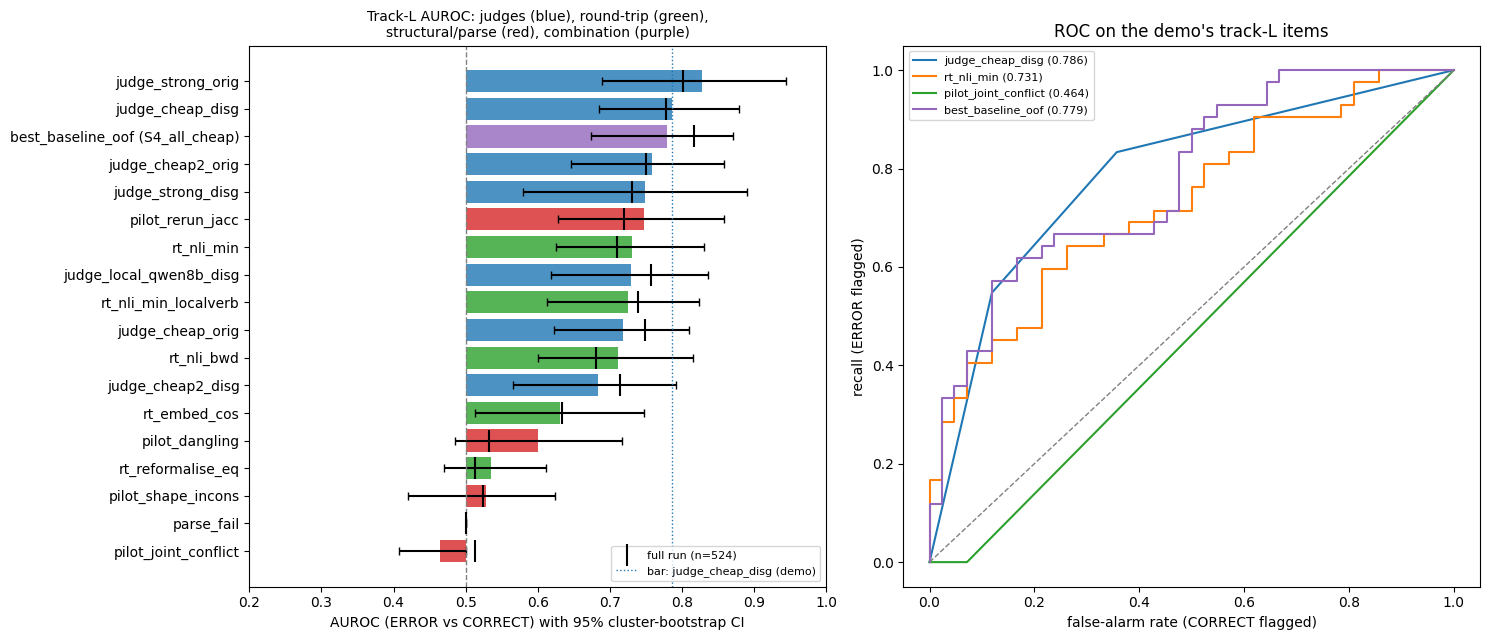

In [19]:
R = A["sets"]["L_primary"]
full = data["metadata"]["full_run_L_primary"]["auroc"]
show = ["judge_strong_orig", "judge_strong_disg", "judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_orig", "judge_cheap2_disg",
        "judge_local_qwen8b_disg", "rt_nli_min_localverb", "rt_nli_min", "rt_nli_bwd", "rt_embed_cos", "rt_reformalise_eq",
        "pilot_rerun_jacc", "pilot_dangling", "pilot_joint_conflict", "pilot_shape_incons", "parse_fail"]
tab = []
for m in show:
    r = R["metrics"][m]
    if r.get("auroc") is None:
        continue
    tab.append({"metric": m, "n": r["n_applicable"], "AUROC": r["auroc"], "CI_lo": r["auroc_ci"][0], "CI_hi": r["auroc_ci"][1],
                "FA@thr": r["fa"], "recall@thr": r["recall"], "coverage": r["coverage"], "full_run_AUROC": full[m]["auroc"]})
cb = A["baseline_combination"]["L_primary"]
tab.append({"metric": f"best_baseline_oof ({cb['best']['set']})", "n": R["n"], "AUROC": cb["best"]["oof_auroc"],
            "CI_lo": cb["best"]["ci"][0], "CI_hi": cb["best"]["ci"][1], "FA@thr": None, "recall@thr": None, "coverage": 1.0,
            "full_run_AUROC": data["metadata"]["full_run_L_primary"]["best_combination"]["oof_auroc"]})
df = pd.DataFrame(tab).sort_values("AUROC", ascending=False).reset_index(drop=True)
pd.set_option("display.width", 200)
print(f"Track L, CORRECT vs ERROR: demo n={R['n']} (errors={R['n_pos']}); full run n={data['metadata']['full_run_L_primary']['n']}")
print(df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ax = axes[0]
d2 = df.iloc[::-1]
colors = ["#1f77b4" if n.startswith("judge") else "#2ca02c" if n.startswith("rt_") else "#d62728" if n.startswith(("pilot", "parse")) else "#9467bd"
          for n in d2["metric"]]
ax.barh(d2["metric"], d2["AUROC"] - 0.5, left=0.5, color=colors, alpha=0.8,
        xerr=[d2["AUROC"] - d2["CI_lo"], d2["CI_hi"] - d2["AUROC"]], capsize=3)
ax.scatter(d2["full_run_AUROC"], d2["metric"], marker="|", s=250, color="black", zorder=5, label="full run (n=524)")
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.axvline(R["metrics"]["judge_cheap_disg"]["auroc"], color="#1f77b4", ls=":", lw=1, label="bar: judge_cheap_disg (demo)")
ax.set_xlim(0.2, 1.0)
ax.set_xlabel("AUROC (ERROR vs CORRECT) with 95% cluster-bootstrap CI")
ax.set_title("Track-L AUROC: judges (blue), round-trip (green),\nstructural/parse (red), combination (purple)", fontsize=10)
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
ky = sets["L_primary"]
keys = [k for k, _ in ky]
y = np.array([v for _, v in ky])
curves = {"judge_cheap_disg": [table["judge_cheap_disg"][k] for k in keys], "rt_nli_min": [table["rt_nli_min"][k] for k in keys],
          "pilot_joint_conflict": [table["pilot_joint_conflict"][k] for k in keys]}
for name, vals in curves.items():
    s, app, _ = fill(vals, table["_max"][name])
    fpr, tpr, _ = roc_curve(y[app], s[app])
    ax.plot(fpr, tpr, label=f"{name} ({auc_w(y[app], s[app]):.3f})")
oof_best = np.array([oof_out[k]["best_baseline_oof"] for k in keys])
fpr, tpr, _ = roc_curve(y, oof_best)
ax.plot(fpr, tpr, label=f"best_baseline_oof ({auc_w(y, oof_best):.3f})", color="#9467bd")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
ax.set_xlabel("false-alarm rate (CORRECT flagged)")
ax.set_ylabel("recall (ERROR flagged)")
ax.set_title("ROC on the demo's track-L items")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()